# Data Analytics Case Study 3: Project
Bruno Sassi - NF1008627

Maria Aguilar - NF1009877

Luciana Popa - NF1005554

Tiago Ceolato – NF1006634

### Libraries

In [1]:
# Importing libraries for the GOOGL stock price prediction, using
# Multiple linear regression and Gradient boosting.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor


In [2]:
# Evaluation helper:
def _eval(y_true, y_pred):
    # Ensure y_true is a Series with same index as predictions
    if not isinstance(y_true, pd.Series):
        y_true = pd.Series(y_true)
    if isinstance(y_pred, pd.Series):
        y_pred_index = y_pred.index
        y_true = pd.Series(y_true.values, index=y_pred_index)
    rmse = float(np.sqrt(((y_true - y_pred)**2).mean()))
    mae  = float((y_true - y_pred).abs().mean())
    ss_res = ((y_true - y_pred)**2).sum()
    ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = float(1 - ss_res/ss_tot) if ss_tot > 0 else np.nan
    return rmse, mae, r2

In [3]:
# Loading and preparing the dataset:

df = pd.read_csv("alphabet_prepared.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# EDA & Data Visualization

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1236 non-null   datetime64[ns]
 1   Price         1236 non-null   float64       
 2   Open          1236 non-null   float64       
 3   High          1236 non-null   float64       
 4   Low           1236 non-null   float64       
 5   Vol.          1236 non-null   float64       
 6   Change %      1236 non-null   float64       
 7   Return        1236 non-null   float64       
 8   MA10          1236 non-null   float64       
 9   MA20          1236 non-null   float64       
 10  MA50          1236 non-null   float64       
 11  MA200         1236 non-null   float64       
 12  Volatility20  1236 non-null   float64       
 13  Price_lag1    1236 non-null   float64       
 14  Price_lag5    1236 non-null   float64       
 15  RSI           1236 non-null   float64 

In [5]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %,Return,MA10,MA20,...,MA200,Volatility20,Price_lag1,Price_lag5,RSI,MACD,Signal,Year,Month,DayOfWeek
0,2020-08-31,81.48,82.18,82.22,81.27,26420000.0,-0.0060,-0.005978,79.925,77.4070,...,77.251429,0.011754,81.97,79.26,80.113177,1.913178,1.396334,2020,8,Monday
1,2020-09-01,82.75,81.61,82.96,81.48,22680000.0,0.0157,0.015587,80.421,77.8610,...,77.501364,0.011683,81.48,80.29,80.016247,2.026120,1.522291,2020,9,Tuesday
2,2020-09-02,85.87,83.40,86.31,83.01,49520000.0,0.0376,0.037704,81.285,78.4570,...,77.865217,0.013657,82.75,82.21,83.556150,2.340406,1.685914,2020,9,Wednesday
3,2020-09-03,81.48,84.98,85.00,80.39,63730000.0,-0.0512,-0.051124,81.552,78.7685,...,78.015833,0.018715,85.87,81.43,66.666667,2.209772,1.790686,2020,9,Thursday
4,2020-09-04,79.06,80.45,81.75,76.90,55850000.0,-0.0296,-0.029701,81.580,78.9755,...,78.057600,0.020126,81.48,81.97,57.892181,1.889191,1.810387,2020,9,Friday


In [6]:
df.isnull().sum()

Date            0
Price           0
Open            0
High            0
Low             0
Vol.            0
Change %        0
Return          0
MA10            0
MA20            0
MA50            0
MA200           0
Volatility20    0
Price_lag1      0
Price_lag5      0
RSI             0
MACD            0
Signal          0
Year            0
Month           0
DayOfWeek       0
dtype: int64

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,1236,2023-02-13 09:35:32.038834944,2020-08-31 00:00:00,2021-11-18 18:00:00,2023-02-13 12:00:00,2024-05-07 06:00:00,2025-08-01 00:00:00,NaN
Price,1236.0,132.223528,70.47,106.7875,132.585,155.0275,206.38,30.803291
Open,1236.0,132.170704,70.13,106.5475,132.68,155.0375,203.39,30.829658
High,1236.0,133.698786,71.9,107.95,133.77,157.19,207.05,31.054294
Low,1236.0,130.721003,70.11,105.08,130.88,152.84,202.81,30.545428
Vol.,1236.0,32255800.970874,9310000.0,23330000.0,28875000.0,36910000.0,127750000.0,13728810.644266
Change %,1236.0,0.000869,-0.0951,-0.009725,0.0014,0.0115,0.1022,0.019619
Return,1236.0,0.000869,-0.095094,-0.009721,0.001378,0.011526,0.102244,0.019618
MA10,1236.0,131.815354,72.447,106.102,132.817,155.11825,199.158,30.580493
MA20,1236.0,131.367633,73.439,105.87675,133.419,155.33525,196.6555,30.43204


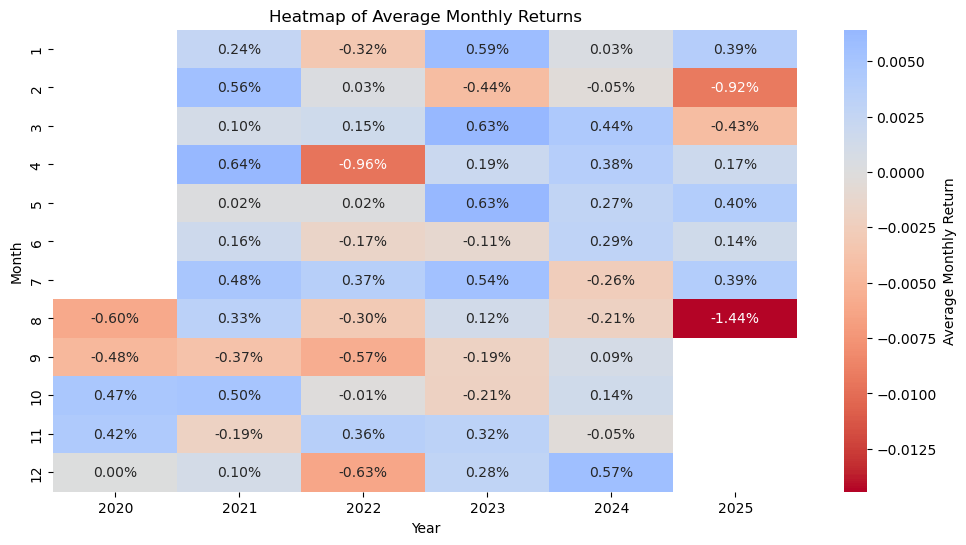

In [8]:
# created a heatmap of avg monthly returns ("Return") to visualize correlations between different months.

# Group by Year and Month, pivot into matrix
monthly_returns = df.groupby(['Year', 'Month'])['Return'].mean().unstack()

# Drop months (rows) with missing values across all years
monthly_returns = monthly_returns.dropna(how='all')

# Transpose so Months are rows, Years are columns
monthly_returns_matrix = monthly_returns.T

# Plot heatmap with midpoint at 0
plt.figure(figsize=(12, 6))
sns.heatmap(
    monthly_returns_matrix,
    annot=True,
    fmt=".2%",
    cmap="coolwarm_r",
    center=0,  # ensures color scale midpoint is 0
    cbar_kws={'label': 'Average Monthly Return'}
)
plt.title('Heatmap of Average Monthly Returns')
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()



In [9]:
# --- Imports
from scipy import stats

df_test = df.copy()
df_test["month_name"] = pd.to_datetime(df_test['Date']).dt.month_name()

# A simple volatility proxy: absolute daily return
df_test["abs_ret"] = df_test["Return"].abs()

# Optional: log-volume (helps with heavy right-skew)
df_test["log_vol"] = np.log(df['Vol.'].replace(0, np.nan))

# ---------------------------------------------------------------------------------
# 1) February vs others: ANOVA across months + Welch t-test (Feb vs rest)

# ANOVA across 12 months
groups = [g["Return"].values for _, g in df_test.groupby("Month")]
anova_F, anova_p = stats.f_oneway(*groups)

# Welch t-test: February vs all other months
feb_returns = df_test.loc[df_test["Month"] == 2, "Return"].values
other_returns = df_test.loc[df_test["Month"] != 2, "Return"].values
t_stat, t_p = stats.ttest_ind(feb_returns, other_returns, equal_var=False, nan_policy="omit")

# Effect size (Cohen's d for independent groups)
def cohens_d(a, b):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    na, nb = len(a), len(b)
    sa2, sb2 = a.var(ddof=1), b.var(ddof=1)
    sp2 = ((na - 1)*sa2 + (nb - 1)*sb2) / (na + nb - 2)
    return (a.mean() - b.mean()) / np.sqrt(sp2)

d = cohens_d(feb_returns, other_returns)

# ---------------------------------------------------------------------------------
# 2) Volume–volatility relationship:
#    (a) Spearman correlation between log(volume) and |return|
#    (b) Chi-square test: high-volume (top 25%) vs high-volatility (top 25%)

# (a) Spearman (rank) correlation
spearman_rho, spearman_p = stats.spearmanr(df_test["log_vol"], df_test["abs_ret"], nan_policy="omit")

# (b) Chi-square 2x2
vol_thresh = df_test["log_vol"].quantile(0.75)
vol_high = df_test["log_vol"] >= vol_thresh

vola_thresh = df_test["abs_ret"].quantile(0.75)
vola_high = df_test["abs_ret"] >= vola_thresh

ct = pd.crosstab(vol_high, vola_high)
chi2, chi2_p, dof, expected = stats.chi2_contingency(ct)

# ---------------------------------------------------------------------------------
# 3) Normality of returns (fat tails): Jarque–Bera
jb_stat, jb_p = stats.jarque_bera(df_test["Return"].dropna())

# ---------------------------------------------------------------------------------
# Outputs

summary = {
    "ANOVA_months": {"F": anova_F, "p_value": anova_p},
    "Welch_t_Feb_vs_Rest": {
        "t": t_stat, "p_value": t_p,
        "mean_Feb": np.nanmean(feb_returns),
        "mean_Others": np.nanmean(other_returns),
        "Cohen_d": d,
        "n_Feb": int(np.isfinite(feb_returns).sum()),
        "n_Others": int(np.isfinite(other_returns).sum())
    },
    "Spearman_logVol_vs_absRet": {"rho": spearman_rho, "p_value": spearman_p},
    "Chi2_highVol_vs_highVolatility": {
        "chi2": chi2, "p_value": chi2_p, "dof": dof,
        "contingency_table": ct.to_dict()
    },
    "JarqueBera_Returns": {"JB": jb_stat, "p_value": jb_p}
}

import pprint
pprint.pp(summary)


{'ANOVA_months': {'F': 0.8437323848636663, 'p_value': 0.5960654118465325},
 'Welch_t_Feb_vs_Rest': {'t': -1.0783621296459327,
                         'p_value': 0.2833357020890446,
                         'mean_Feb': -0.0016486502680450636,
                         'mean_Others': 0.0010809828058722343,
                         'Cohen_d': -0.13917731320489363,
                         'n_Feb': 96,
                         'n_Others': 1140},
 'Spearman_logVol_vs_absRet': {'rho': 0.46721710653518067,
                               'p_value': 4.9428560794835805e-68},
 'Chi2_highVol_vs_highVolatility': {'chi2': 179.22905429701547,
                                    'p_value': 7.140867828815519e-41,
                                    'dof': 1,
                                    'contingency_table': {False: {False: 784,
                                                                  True: 143},
                                                          True: {False: 143,
               

In [10]:
# Add-on: March/April Welch tests + Kruskal–Wallis
def welch_month_vs_rest(month_int, dfm):
    a = dfm.loc[dfm["Month"] == month_int, "Return"].values
    b = dfm.loc[dfm["Month"] != month_int, "Return"].values
    t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    return {
        "t": t,
        "p_value": p,
        "mean_month": float(np.nanmean(a)),
        "mean_others": float(np.nanmean(b)),
        "Cohen_d": float(cohens_d(a, b)),
        "n_month": int(np.isfinite(a).sum()),
        "n_others": int(np.isfinite(b).sum())
    }

# Welch tests for March (3) and April (4)
welch_march  = welch_month_vs_rest(3, df_test)
welch_april  = welch_month_vs_rest(4, df_test)

# Kruskal–Wallis (nonparametric ANOVA) across months
kruskal_H, kruskal_p = stats.kruskal(
    *[g["Return"].dropna().values for _, g in df_test.groupby("Month")]
)

# Extend the existing summary dict (create if missing)
if "summary" not in globals():
    summary = {}

summary.update({
    "Welch_t_Mar_vs_Rest": welch_march,
    "Welch_t_Apr_vs_Rest": welch_april,
    "KruskalWallis_months": {"H": float(kruskal_H), "p_value": float(kruskal_p)}
})

import pprint
pprint.pp(summary)


{'ANOVA_months': {'F': 0.8437323848636663, 'p_value': 0.5960654118465325},
 'Welch_t_Feb_vs_Rest': {'t': -1.0783621296459327,
                         'p_value': 0.2833357020890446,
                         'mean_Feb': -0.0016486502680450636,
                         'mean_Others': 0.0010809828058722343,
                         'Cohen_d': -0.13917731320489363,
                         'n_Feb': 96,
                         'n_Others': 1140},
 'Spearman_logVol_vs_absRet': {'rho': 0.46721710653518067,
                               'p_value': 4.9428560794835805e-68},
 'Chi2_highVol_vs_highVolatility': {'chi2': 179.22905429701547,
                                    'p_value': 7.140867828815519e-41,
                                    'dof': 1,
                                    'contingency_table': {False: {False: 784,
                                                                  True: 143},
                                                          True: {False: 143,
               

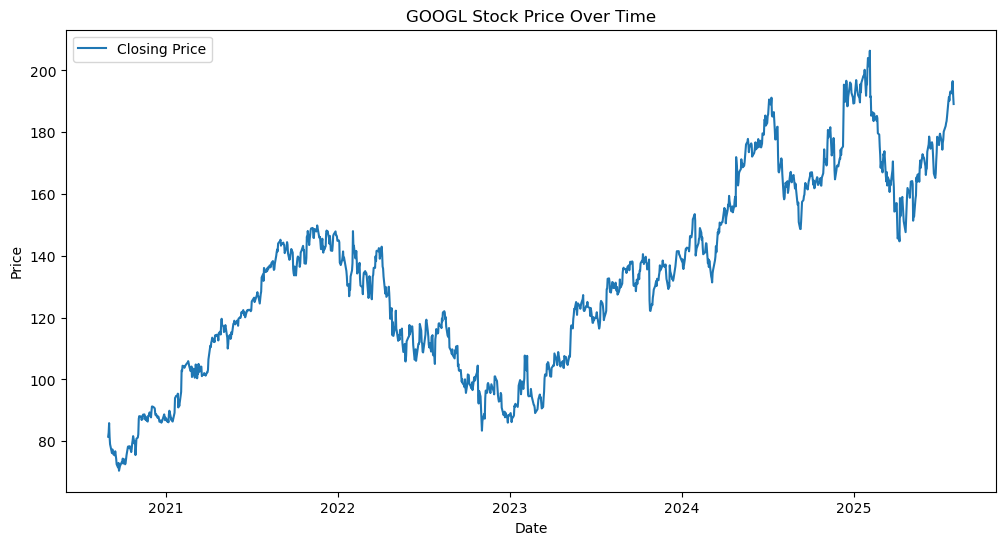

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], label='Closing Price')
plt.title("GOOGL Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

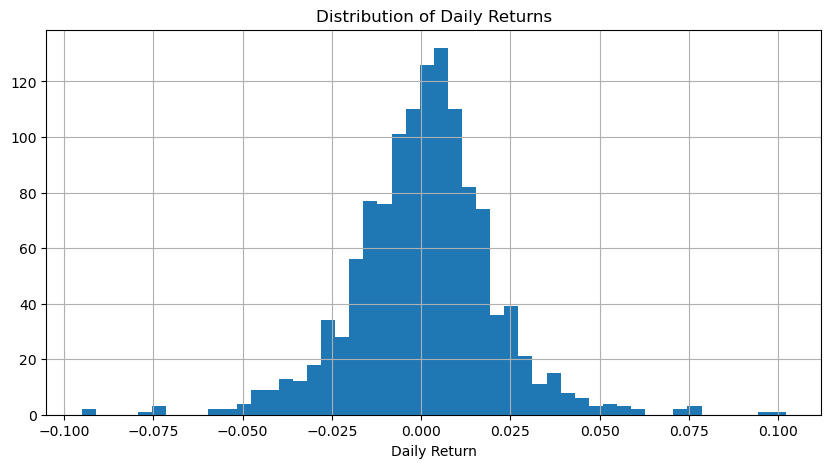

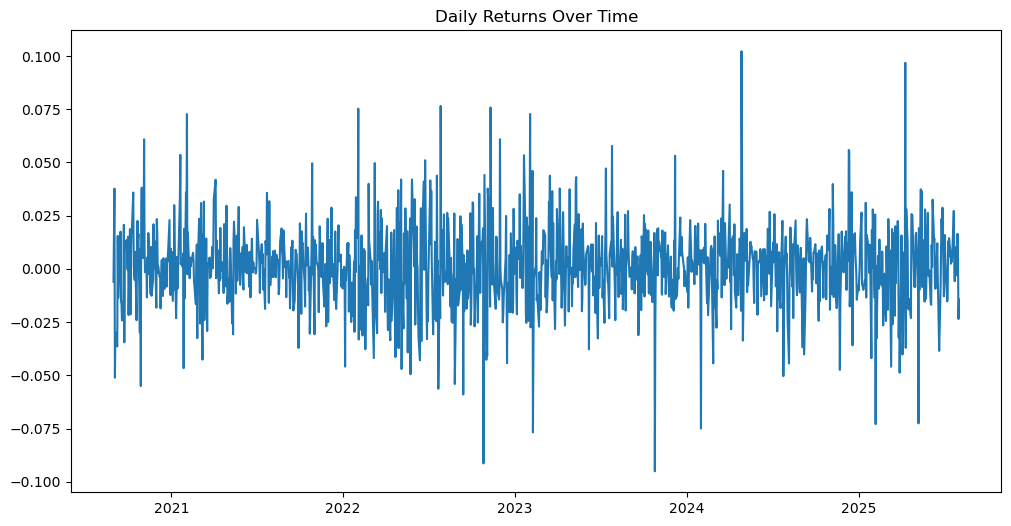

In [12]:
plt.figure(figsize=(10,5))
df['Return'].hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Return'], label='Daily Return')
plt.title("Daily Returns Over Time")
plt.show()


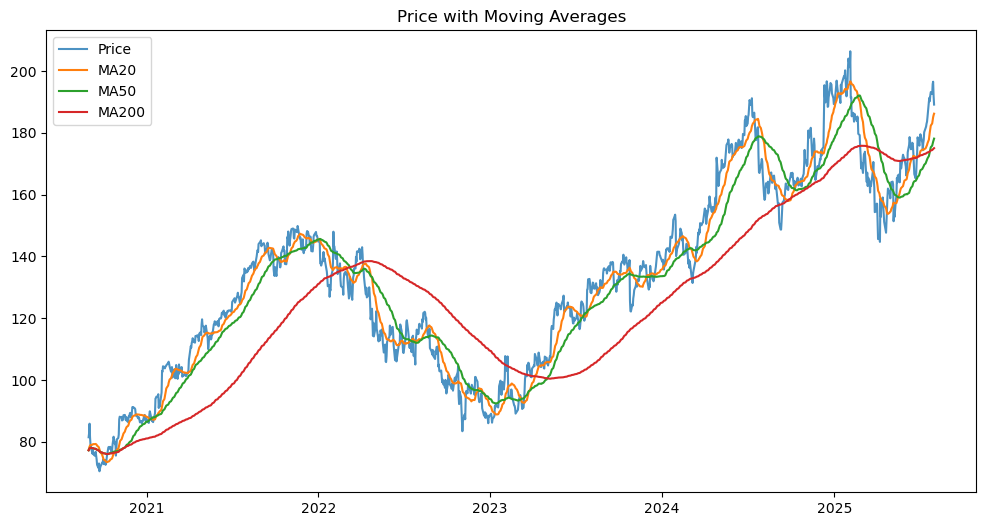

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], label='Price', alpha=0.8)
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')
plt.plot(df['Date'], df['MA200'], label='MA200')
plt.title("Price with Moving Averages")
plt.legend()
plt.show()

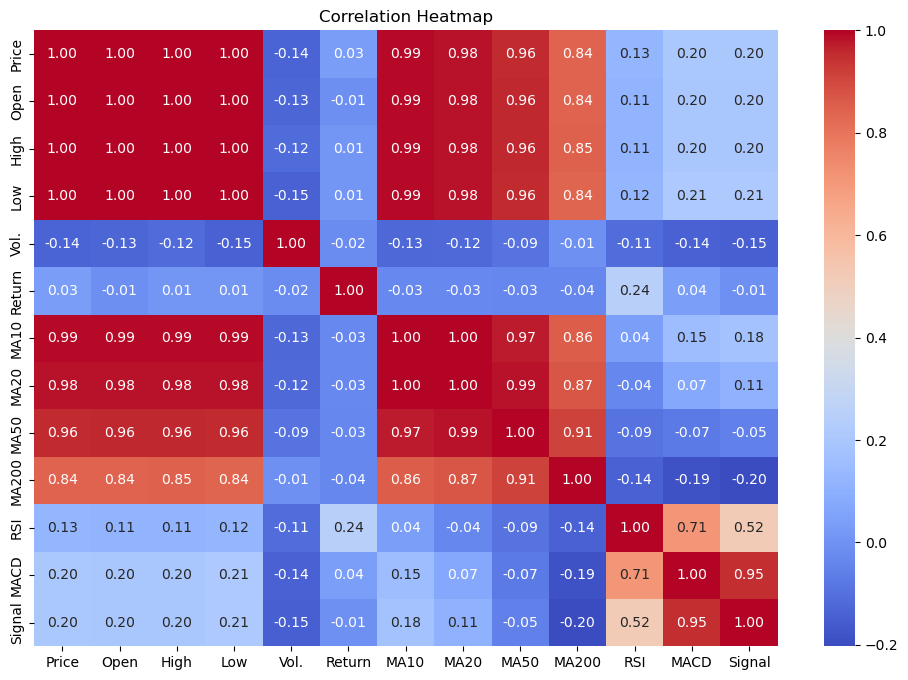

In [14]:
plt.figure(figsize=(12,8))
corr = df[['Price','Open','High','Low','Vol.','Return','MA10','MA20','MA50','MA200','RSI','MACD','Signal']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


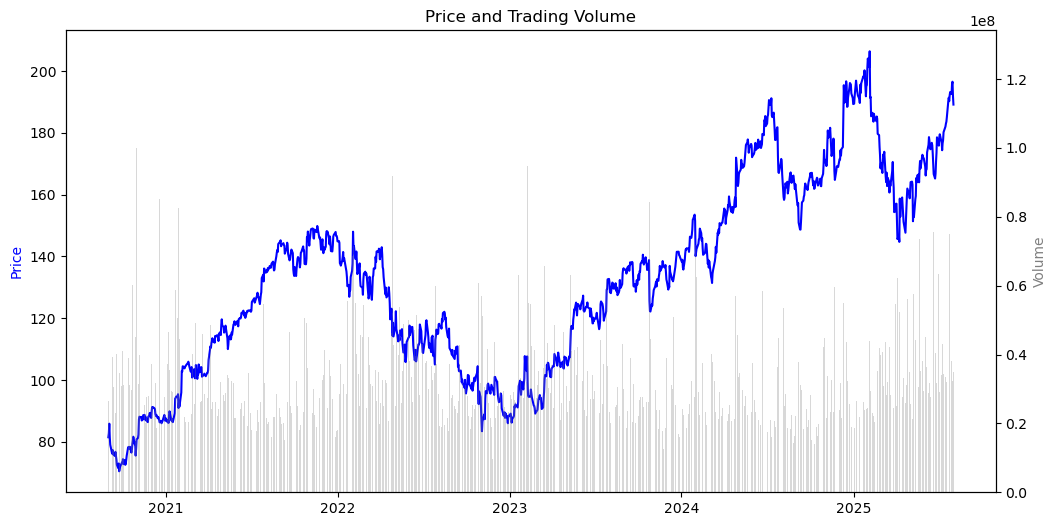

In [15]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df['Date'], df['Price'], color='blue', label='Price')
ax1.set_ylabel("Price", color="blue")
ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Vol.'], alpha=0.3, color='gray', label='Volume')
ax2.set_ylabel("Volume", color="gray")

plt.title("Price and Trading Volume")
plt.show()

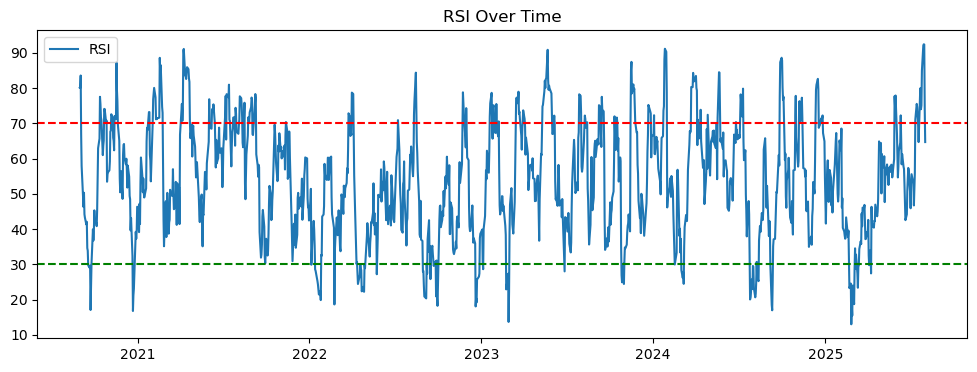

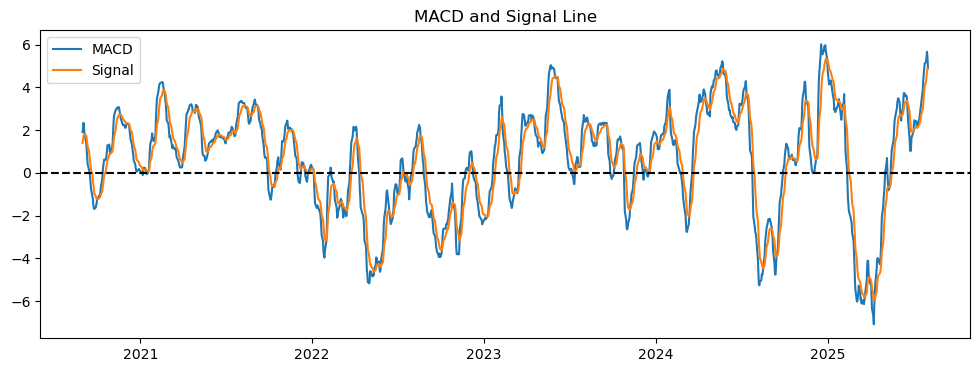

In [16]:
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['Signal'], label='Signal')
plt.axhline(0, color='black', linestyle='--')
plt.title("MACD and Signal Line")
plt.legend()
plt.show()


# Data prep and Feature Engineering

Creating the target variable (which is the next-day closing price)


In [17]:
df['y_next'] = df['Price'].shift(-1)

In [18]:
# Selecting features for H1, including lagged prices only:

features_A = ['Price_lag1', 'Price_lag5']

# Selecting features for H2 and H3, which are the lagged proces and the technical indicators:

features_B = features_A + [
    'MA10','MA20','MA50','MA200',
    'RSI','MACD','Signal','Volatility20','Vol.'
]

# The MovingAvg_10day is the short-term average, the MovingAvg_20day is the medium-term average.
# MovingAvg_50day is a medium/long-term average, and MovingAvg_200day is a long-term average.


In [19]:
# Dropping rows with missing/null values:

df = df.dropna(subset=features_B + ['y_next'])

X_A = df[features_A]   # for model A
X_B = df[features_B]   # for model B and gradient booting
y = df['y_next']     # target (next day closing price)
dates = df['Date']

In [20]:
# Separating data chronologically:

train_idx = dates < "2024-01-01"   # our training data (2021-2023)
valid_idx = (dates >= "2024-01-01") & (dates < "2025-01-01") # just a validation data (2024)
test_idx  = dates >= "2025-01-01"   # our testing data (2025)

### Calculating evaluation metrics:

In [21]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "RMSE": root_mean_squared_error(y_true, y_pred),  # this will be our avg predictor error
        "MAE": mean_absolute_error(y_true, y_pred),    # error in monetary value
        "R2": r2_score(y_true, y_pred)    # % of the variance explained
    }

results = []

# Model Building

### **Multiple Linear Regression**

In [22]:
# Model A (H1):

pipe_lr_A = Pipeline([
    ("scaler", StandardScaler()),      # normalizing data so we can compare them properly
    ("lr", LinearRegression())
])
pipe_lr_A.fit(X_A[train_idx], y[train_idx])
results.append(evaluate_model("LR_A (lags) - Valid", y[valid_idx], pipe_lr_A.predict(X_A[valid_idx])))
results.append(evaluate_model("LR_A (lags) - Test",  y[test_idx],  pipe_lr_A.predict(X_A[test_idx])))

In [23]:
# Model B (H2):

pipe_lr_B = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
pipe_lr_B.fit(X_B[train_idx], y[train_idx])
results.append(evaluate_model("LR_B (lags+tech) - Valid", y[valid_idx], pipe_lr_B.predict(X_B[valid_idx])))
results.append(evaluate_model("LR_B (lags+tech) - Test",  y[test_idx],  pipe_lr_B.predict(X_B[test_idx])))

In [24]:
# Most relevant coefficients obtained from Model B:

coef_B = pd.Series(pipe_lr_B.named_steps['lr'].coef_, index=features_B).sort_values(key=abs, ascending=False)
print("\nTop 10 Linear Regression Coefficients (Model B):")
print(coef_B.head(10))


Top 10 Linear Regression Coefficients (Model B):
MA20          33.319387
Signal       -14.513219
MACD          14.146572
MA50         -11.955598
MA10           9.149862
Price_lag1    -7.194964
Price_lag5    -2.658615
MA200         -1.380593
RSI            1.092320
Vol.           0.099249
dtype: float64


With the previous output we have the expected change
in the target variable (next day closing price)
when there is a increase of 1 unit on the predictor, while keeping other variables constant.
MA20 shows that for every 1 unit increase in the 20 day moving avg, the predicted target will increase by 33.31 units.
Signal shows that for every 1 unit increase in signal, the predictor will decrease by 14,51 units.
We can see that the most influential coefficients are MA20, Signal, MACD, and also MA50 which are larger compared to the others.

In [25]:
# print results in table format
for res in results:
    print(f"{res['Model']:<25}: RMSE={res['RMSE']:.4f}  |      MAE={res['MAE']:.4f}   |      R2={res['R2']:.4f}")

LR_A (lags) - Valid      : RMSE=4.2695  |      MAE=3.2456   |      R2=0.9227
LR_A (lags) - Test       : RMSE=4.8543  |      MAE=3.9463   |      R2=0.8886
LR_B (lags+tech) - Valid : RMSE=3.6179  |      MAE=2.7511   |      R2=0.9445
LR_B (lags+tech) - Test  : RMSE=4.8712  |      MAE=3.9550   |      R2=0.8878


### **Gradient Boosting**

In [26]:
# Model C (H3):
gb = GradientBoostingRegressor(random_state=42)

# Adjusting the parameters:
param_grid = {
    'n_estimators': [100, 200],         # number of trees
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.8, 1.0]
}

# TimeSeriesSplit: preserves order of data
tscv = TimeSeriesSplit(n_splits=5)

# Grid search with time-series CV
grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit only on training+validation (exclude test)
grid_gb.fit(X_B[train_idx | valid_idx], y[train_idx | valid_idx])

# Save CV results to CSV
cv_results_gb = pd.DataFrame(grid_gb.cv_results_)
cv_results_gb.to_csv("gb_cv_results.csv", index=False)

# Best parameters and CV score
print("Best parameters (GB):", grid_gb.best_params_)
print("Best CV RMSE:", -grid_gb.best_score_)

# Evaluate on test set
y_pred_gb = grid_gb.best_estimator_.predict(X_B[test_idx])
rmse_gb = root_mean_squared_error(y[test_idx], y_pred_gb)
mae_gb = mean_absolute_error(y[test_idx], y_pred_gb)
r2_gb = r2_score(y[test_idx], y_pred_gb)

print(f"Test RMSE: {rmse_gb:.4f}, MAE: {mae_gb:.4f}, R²: {r2_gb:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters (GB): {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
Best CV RMSE: 12.24093274064192
Test RMSE: 7.8215, MAE: 6.5105, R²: 0.7108


### Gradient Boosting with Time-Series CV:
* We used `TimeSeriesSplit` (5 folds) to avoid look-ahead bias.  
* The best configuration was: `n_estimators=..., learning_rate=..., max_depth=..., subsample=...`.  

In [27]:
# Showing feature importances from the gradient boosting model:
gb_importance = pd.Series(grid_gb.best_estimator_.feature_importances_, index=features_B).sort_values(ascending=False)
print("\nTop 10 Gradient Boosting Feature Importances:")
print(gb_importance.head(10))


Top 10 Gradient Boosting Feature Importances:
Price_lag1    0.810433
MA10          0.135251
MA20          0.040361
Price_lag5    0.007071
MA200         0.002102
RSI           0.002006
MA50          0.001846
Vol.          0.000631
Signal        0.000151
MACD          0.000109
dtype: float64


The previuos output shows how much each feature contributes to reducing error in the ensemble trees.
Price_lag1 is the main feature, with 81% importance.
 It indicates that the previous day price (Price_lag1) is the most predictive feature in this model.
When analysing data with this model we can get the dominant feature, even if the linear coefficient was smaller, for example.

In [28]:
# Gradient Boosting (fast default):
from sklearn.ensemble import GradientBoostingRegressor

gb_params = {
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.1,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "random_state": 42
}

gb_model = GradientBoostingRegressor(**gb_params)
gb_model.fit(X_B[train_idx | valid_idx], y[train_idx | valid_idx])

# Evaluate if needed:
gb_valid_pred = gb_model.predict(X_B[valid_idx])
gb_test_pred  = gb_model.predict(X_B[test_idx])

rmse_v, mae_v, r2_v = _eval(y[valid_idx], gb_valid_pred)
rmse_t, mae_t, r2_t = _eval(y[test_idx], gb_test_pred)

results.append({"Model":"GB - Valid","RMSE":rmse_v,"MAE":mae_v,"R2":r2_v})
results.append({"Model":"GB - Test","RMSE":rmse_t,"MAE":mae_t,"R2":r2_t})


print({"Model":"GB - Valid","RMSE":rmse_v,"MAE":mae_v,"R2":r2_v})
print({"Model":"GB - Test","RMSE":rmse_t,"MAE":mae_t,"R2":r2_t})

{'Model': 'GB - Valid', 'RMSE': 0.599803456105697, 'MAE': 0.44648618731924383, 'R2': 0.9984738447789483}
{'Model': 'GB - Test', 'RMSE': 6.945928628678186, 'MAE': 5.491369540340976, 'R2': 0.7719510358276278}


### **ARIMA**

In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA  # <-- ARIMA only

# --- 1) Series on BUSINESS days (no fake weekends) ---
series = (
    df.set_index("Date")["Price"]
      .sort_index()
      .asfreq("B")           # business days
      .ffill()
)
series.index = pd.to_datetime(series.index)

# Keep your splits
dates = pd.to_datetime(df["Date"])
train_end  = df.loc[dates < "2024-01-01", "Date"].max()
valid_dates = pd.to_datetime(df.loc[(dates >= "2024-01-01") & (dates < "2025-01-01"), "Date"].sort_values())
test_dates  = pd.to_datetime(df.loc[dates >= "2025-01-01", "Date"].sort_values())

# Align y_next to the B-day calendar (so truth lines up with predictions)
y_next = (
    df.set_index("Date")["y_next"]
      .sort_index()
      .reindex(series.index)
)

# --- 2) Order selection on TRAIN ONLY (same candidates) ---
cand = [(1,1,0),(1,1,1),(2,1,1),(5,1,0)]
best_order, best_aic = None, np.inf
train_series = series.loc[:train_end]

for order in cand:
    try:
        # trend='c' -> constant becomes DRIFT when d>=1 (good for prices)
        res = ARIMA(train_series, order=order, trend='c').fit()
        if res.aic < best_aic:
            best_order, best_aic = order, res.aic
    except Exception:
        continue

if best_order is None:
    best_order = (1,1,1)

print(f"[ARIMA] Using order {best_order} (AIC≈{best_aic:.2f}), trend='c' (drift)")

# --- 3) Rolling 1-step ahead forecasts (expanding window) ---
def arima_one_step(series, forecast_dates, order, trend='c', refit_every=30):
    preds = []
    last_fit = None
    last_fit_end = None
    b_index = series.index

    for i, d in enumerate(pd.to_datetime(forecast_dates)):
        # find the last observed day BEFORE d on the B-day index
        pos = b_index.searchsorted(d)
        if pos == 0:
            continue  # no history before d
        hist_end = b_index[pos-1]
        hist = series.loc[:hist_end]

        # refit occasionally for speed
        if (last_fit is None) or (i % refit_every == 0) or (last_fit_end != hist_end):
            last_fit = ARIMA(hist, order=order, trend=trend).fit()
            last_fit_end = hist_end

        # 1-step ahead forecast (target is value at d)
        fc = last_fit.get_forecast(steps=1)
        preds.append((d, float(fc.predicted_mean.iloc[0])))

    return pd.Series({d: p for d, p in preds})

arima_valid_pred = arima_one_step(series, valid_dates, best_order, trend='t')
arima_test_pred  = arima_one_step(series, test_dates,  best_order, trend='t')

# --- 4) Align truths (y_next == next-day price) ---
y_valid_true = y_next.reindex(arima_valid_pred.index)
y_test_true  = y_next.reindex(arima_test_pred.index)

# --- 5) Evaluation ---
def _eval(y_true, y_pred):
    m = pd.concat([y_true, y_pred], axis=1).dropna()
    yt, yp = m.iloc[:,0], m.iloc[:,1]
    rmse = float(np.sqrt(((yt - yp)**2).mean()))
    mae  = float((yt - yp).abs().mean())
    ss_res = ((yt - yp)**2).sum()
    ss_tot = ((yt - yt.mean())**2).sum()
    r2 = float(1 - ss_res/ss_tot) if ss_tot > 0 else np.nan
    return rmse, mae, r2

rmse_v, mae_v, r2_v = _eval(y_valid_true, arima_valid_pred)
rmse_t, mae_t, r2_t = _eval(y_test_true,  arima_test_pred)

print(f"ARIMA {best_order} (drift) - Valid: RMSE={rmse_v:.3f} | MAE={mae_v:.3f} | R2={r2_v:.3f}")
print(f"ARIMA {best_order} (drift) - Test : RMSE={rmse_t:.3f} | MAE={mae_t:.3f} | R2={r2_t:.3f}")

# (optional) store in your results table
results.append({"Model":"ARIMA(roll-1, drift) - Valid","RMSE":rmse_v,"MAE":mae_v,"R2":r2_v})
results.append({"Model":"ARIMA(roll-1, drift) - Test", "RMSE":rmse_t,"MAE":mae_t,"R2":r2_t})


[ARIMA] Using order (1, 1, 1) (AIC≈inf), trend='c' (drift)
ARIMA (1, 1, 1) (drift) - Valid: RMSE=4.228 | MAE=3.183 | R2=0.924
ARIMA (1, 1, 1) (drift) - Test : RMSE=4.909 | MAE=3.881 | R2=0.886


In [30]:
# print results in table format
for res in results:
    print(f"{res['Model']:<25}: RMSE={res['RMSE']:.4f}  |      MAE={res['MAE']:.4f}   |      R2={res['R2']:.4f}")

LR_A (lags) - Valid      : RMSE=4.2695  |      MAE=3.2456   |      R2=0.9227
LR_A (lags) - Test       : RMSE=4.8543  |      MAE=3.9463   |      R2=0.8886
LR_B (lags+tech) - Valid : RMSE=3.6179  |      MAE=2.7511   |      R2=0.9445
LR_B (lags+tech) - Test  : RMSE=4.8712  |      MAE=3.9550   |      R2=0.8878
GB - Valid               : RMSE=0.5998  |      MAE=0.4465   |      R2=0.9985
GB - Test                : RMSE=6.9459  |      MAE=5.4914   |      R2=0.7720
ARIMA(roll-1, drift) - Valid: RMSE=4.2283  |      MAE=3.1834   |      R2=0.9242
ARIMA(roll-1, drift) - Test: RMSE=4.9086  |      MAE=3.8811   |      R2=0.8861


In [31]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Load and prepare the dataset

df = pd.read_csv("alphabet_prepared.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Define train/test split

split_idx = int(len(df) * 0.8)  # 80% train, 20% test
train_data = df['Price'][:split_idx]
test_data = df['Price'][split_idx:]

# ARIMA parameters (adjust as needed)
p, d, q = 1, 1, 1  # example order from your previous ARIMA fitting

# 1. Rolling Window Forecast
window_size = 60  # adjust based on dataset length
rolling_predictions = []

for i in range(len(test_data)):
    if i + window_size > len(df):
        break
    train_window = df['Price'][i : i + window_size]
    model = ARIMA(train_window, order=(p, d, q))
    model_fit = model.fit()
    pred = model_fit.forecast(steps=1)
    rolling_predictions.append(pred.iloc[0])

rolling_mse = mean_squared_error(test_data[:len(rolling_predictions)], rolling_predictions)
print("Rolling window MSE:", rolling_mse)

# 2. Out-of-Time Test
train_sizes = [100, 120, 140]  # adjust to dataset length
for size in train_sizes:
    if size + 10 > len(df):
        continue  # skip if out of bounds
    train = df['Price'][:size]
    test = df['Price'][size:size+10]  # next 10 steps as test
    model = ARIMA(train, order=(p, d, q))
    model_fit = model.fit()
    pred = model_fit.forecast(steps=10)
    mse_oot = mean_squared_error(test, pred)
    print(f"Out-of-time test - Train size {size}, MSE:", mse_oot)

Rolling window MSE: 3474.0151439345227
Out-of-time test - Train size 100, MSE: 25.94618737797478
Out-of-time test - Train size 120, MSE: 2.5355731616016457
Out-of-time test - Train size 140, MSE: 19.147333541643924


### **Random Forest**

In [32]:
# Fast but reliable RF settings:
rf_params = {
    "n_estimators": 200,       # enough trees for stable predictions
    "max_depth": 10,           # limit depth to reduce runtime
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "random_state": 42,
    "n_jobs": -1               # use all cores
}

# Train on train + validation:
best_rf = RandomForestRegressor(**rf_params)
best_rf.fit(X_B[train_idx | valid_idx], y[train_idx | valid_idx])

# Predict on validation and test:
rf_valid_pred = best_rf.predict(X_B[valid_idx])
rf_test_pred  = best_rf.predict(X_B[test_idx])

# Evaluation (robust to numpy or pandas):
def _eval(y_true, y_pred):
    # Convert y_true to pd.Series aligned with y_pred
    if isinstance(y_true, np.ndarray):
        y_true = pd.Series(y_true, index=range(len(y_true)))
    if isinstance(y_pred, np.ndarray):
        y_pred = pd.Series(y_pred, index=y_true.index)
    rmse = float(np.sqrt(((y_true - y_pred)**2).mean()))
    mae  = float((y_true - y_pred).abs().mean())
    ss_res = ((y_true - y_pred)**2).sum()
    ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = float(1 - ss_res/ss_tot) if ss_tot > 0 else np.nan
    return rmse, mae, r2

# Evaluate:
rmse_v, mae_v, r2_v = _eval(y[valid_idx], rf_valid_pred)
rmse_t, mae_t, r2_t = _eval(y[test_idx],  rf_test_pred)

# Store results:
results.append({"Model":"RF - Valid","RMSE":rmse_v,"MAE":mae_v,"R2":r2_v})
results.append({"Model":"RF - Test", "RMSE":rmse_t,"MAE":mae_t,"R2":r2_t})

print(f"Random Forest - Valid: RMSE={rmse_v:.3f} MAE={mae_v:.3f} R2={r2_v:.3f}")
print(f"Random Forest - Test : RMSE={rmse_t:.3f} MAE={mae_t:.3f} R2={r2_t:.3f}")

Random Forest - Valid: RMSE=1.752 MAE=1.242 R2=0.987
Random Forest - Test : RMSE=6.304 MAE=4.831 R2=0.812


In [33]:
# Evaluate RF on validation and test:
# y_pred_rf = best_rf.predict(X_B[test_idx])
# results.append(evaluate_model("RF - Test", y[test_idx], y_pred_rf))

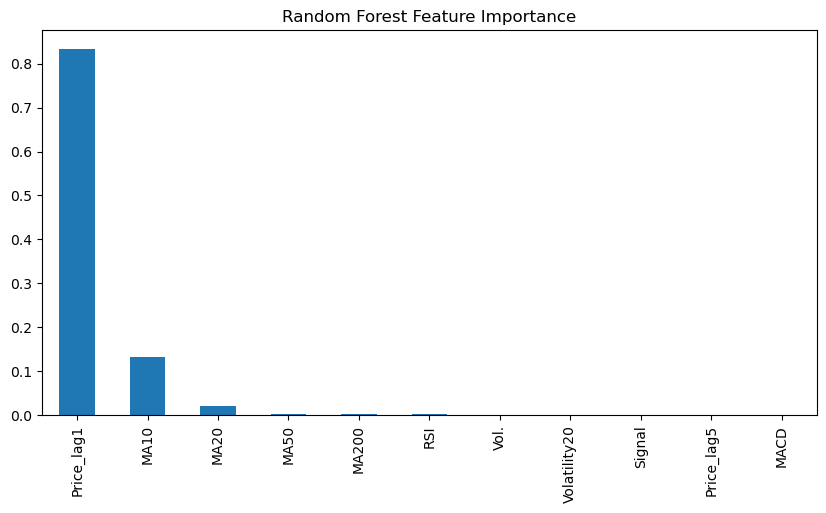

In [34]:
importances = best_rf.feature_importances_
feature_names = X_B.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot feature importance
feat_imp.plot(kind='bar', figsize=(10,5))
plt.title("Random Forest Feature Importance")
plt.show()

In [35]:
# Fast but reliable RF:
rf_params = {
    "n_estimators": 200,
    "max_depth": 10,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "random_state": 42,
    "n_jobs": -1
}

best_rf = RandomForestRegressor(**rf_params)
best_rf.fit(X_B[train_idx | valid_idx], y[train_idx | valid_idx])

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [36]:
# results.append(evaluate_model("RF - Valid",
#                               y[valid_idx],
#                               best_rf.predict(X_B[valid_idx])))

# results.append(evaluate_model("RF - Test",
#                               y[test_idx],
#                               best_rf.predict(X_B[test_idx])))

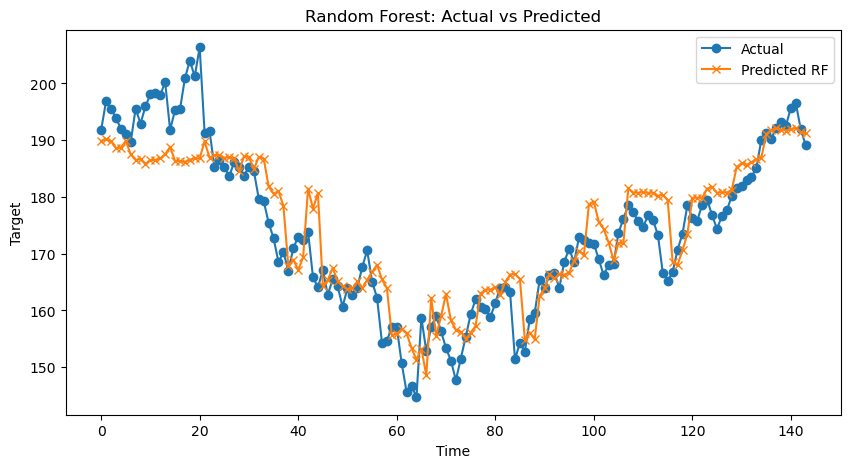

In [37]:
# Evaluate RF on validation and test:
y_pred_rf = best_rf.predict(X_B[test_idx])
plt.figure(figsize=(10,5))
plt.plot(y[test_idx].values, label='Actual', marker='o')
plt.plot(y_pred_rf, label='Predicted RF', marker='x')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Target")
plt.legend()
plt.show()

# Comparing and Visualizing Results

In [38]:
# Final results table:

results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
results_df


Model Evaluation Results:


,Model,RMSE,MAE,R2
0,LR_A (lags) - Valid,4.269505,3.245586,0.922672
1,LR_A (lags) - Test,4.854343,3.946325,0.888615
2,LR_B (lags+tech) - Valid,3.617857,2.751141,0.944476
3,LR_B (lags+tech) - Test,4.871165,3.955049,0.887841
4,GB - Valid,0.599803,0.446486,0.998474
5,GB - Test,6.945929,5.491370,0.771951
6,"ARIMA(roll-1, drift) - Valid",4.228293,3.183434,0.924158
7,"ARIMA(roll-1, drift) - Test",4.908602,3.881096,0.886111
8,RF - Valid,1.752161,1.242455,0.986976
9,RF - Test,6.303632,4.831174,0.812177


In [39]:
# Converting results to DataFrame:
results_df = pd.DataFrame(results)
results_df.sort_values(by='RMSE', inplace=True)
print("\nModel Performance Summary (sorted by RMSE):")
results_df


Model Performance Summary (sorted by RMSE):


,Model,RMSE,MAE,R2
4,GB - Valid,0.599803,0.446486,0.998474
8,RF - Valid,1.752161,1.242455,0.986976
2,LR_B (lags+tech) - Valid,3.617857,2.751141,0.944476
6,"ARIMA(roll-1, drift) - Valid",4.228293,3.183434,0.924158
0,LR_A (lags) - Valid,4.269505,3.245586,0.922672
1,LR_A (lags) - Test,4.854343,3.946325,0.888615
3,LR_B (lags+tech) - Test,4.871165,3.955049,0.887841
7,"ARIMA(roll-1, drift) - Test",4.908602,3.881096,0.886111
9,RF - Test,6.303632,4.831174,0.812177
5,GB - Test,6.945929,5.491370,0.771951


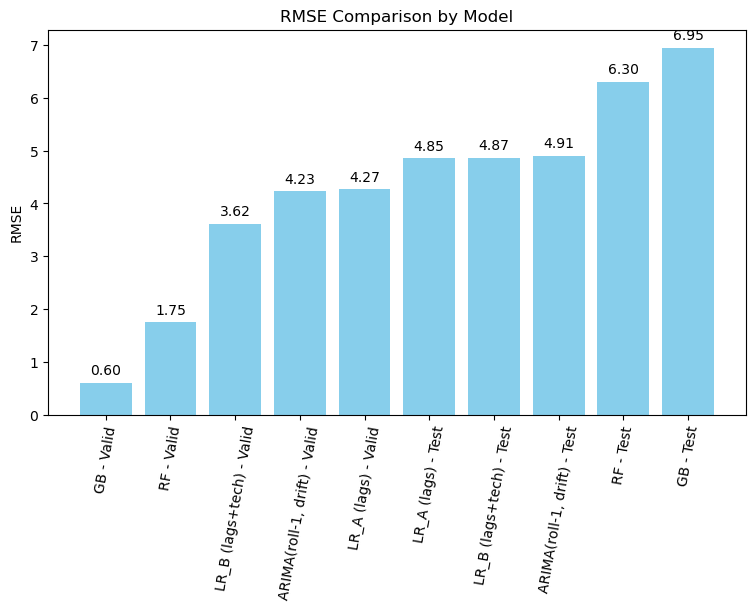

In [40]:
plt.figure(figsize=(9,5))
bars = plt.bar(results_df["Model"], results_df["RMSE"], color="skyblue")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom')
plt.xticks(rotation=80)
plt.title("RMSE Comparison by Model")
plt.ylabel("RMSE")
plt.show()

Validation:

* Gradient Boosting (GB) and Random Forest (RF) are by far the best (RMSE = 0.60 and 1.75).

* Linear regressions (LR_A, LR_B) and ARIMA are in the 3.6–4.3 range, notably worse than tree models.

Test (right side):

* All models see a performance drop in 2025.

* Linear regressions and ARIMA hold up better (~4.8–4.9 RMSE).

* GB and RF probably overfit (RMSE jumps to ~6–7).

**Highlight:** Tree-based methods shine in-sample, but generalize poorly. ARIMA and regressions are less flashy on validation but more stable on unseen data.

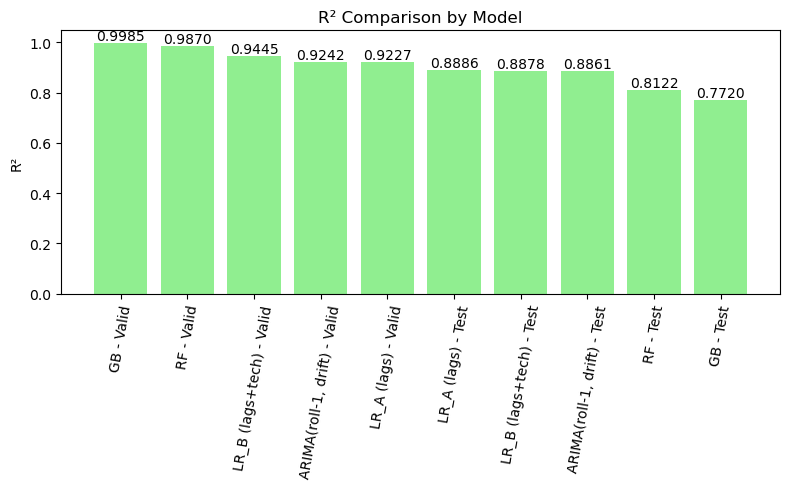

In [41]:
plt.figure(figsize=(8,5))
bars = plt.bar(results_df["Model"], results_df["R2"], color="lightgreen")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", ha='center', va='bottom')
plt.xticks(rotation=80)
plt.title("R² Comparison by Model")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

Validation:

* All models are very high (>0.92). GB (0.999) and RF (0.987) almost perfectly fit the training/validation segment → strong sign of overfitting.

* ARIMA and regressions are lower (~0.92–0.94), but still solid.

Test:

* Clearer separation: regressions and ARIMA remain ~0.88, while RF drops to 0.81 and GB crashes to 0.77.

**Highlight:** On generalization, ARIMA and linear regressions are more trustworthy. The gap between Validation vs Test R² makes overfitting in GB/RF obvious.

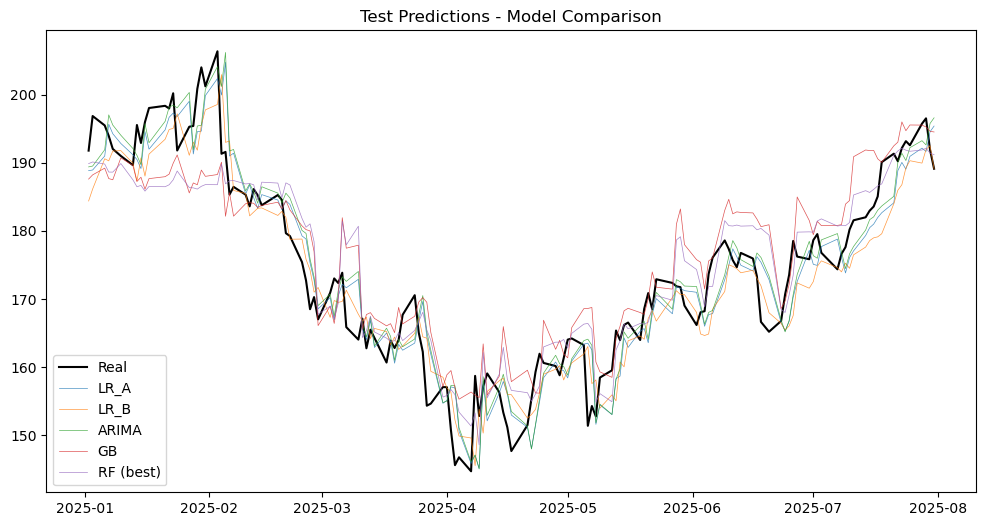

In [42]:
plt.figure(figsize=(12,6))
plt.plot(dates[test_idx], y[test_idx], label="Real", color="black")
plt.plot(dates[test_idx], pipe_lr_A.predict(X_A[test_idx]), label="LR_A", lw=0.5, alpha=0.8)
plt.plot(dates[test_idx], pipe_lr_B.predict(X_B[test_idx]), label="LR_B", lw=0.5, alpha=0.8)
plt.plot(dates[test_idx], arima_test_pred, label="ARIMA", lw=0.5, alpha=0.8)
plt.plot(dates[test_idx], gb_test_pred, label="GB", lw=0.5, alpha=0.8)        # use gb_test_pred
plt.plot(dates[test_idx], rf_test_pred, label="RF (best)", lw=0.5, alpha=0.8)  # use rf_test_pred
plt.title("Test Predictions - Model Comparison")
plt.legend()
plt.show()

# Hypotheses Testing based on results

In [43]:
# H1: R² ≥ 0.70 for lag-only model (Test)
r2_h1 = results_df.loc[results_df.Model=="LR_A (lags) - Test","R2"].iloc[0]
print("H1:", "✅ PASS" if r2_h1 >= 0.70 else "❌ FAIL", f"(Test R²={r2_h1:.4f})")


H1: ✅ PASS (Test R²=0.8886)


In [44]:
# H2: ≥5% RMSE reduction when adding tech indicators (Model B vs A)
rmse_A_v = results_df.loc[results_df.Model=="LR_A (lags) - Valid","RMSE"].iloc[0]
rmse_B_v = results_df.loc[results_df.Model=="LR_B (lags+tech) - Valid","RMSE"].iloc[0]
rmse_A_t = results_df.loc[results_df.Model=="LR_A (lags) - Test","RMSE"].iloc[0]
rmse_B_t = results_df.loc[results_df.Model=="LR_B (lags+tech) - Test","RMSE"].iloc[0]
imp_v = (rmse_A_v - rmse_B_v) / rmse_A_v * 100
imp_t = (rmse_A_t - rmse_B_t) / rmse_A_t * 100
print(f"H2: Valid +{imp_v:.2f}%  |  Test {imp_t:+.2f}%  ->", "✅ PASS on Valid, ❌ FAIL on Test" if imp_t < 5 else "✅ PASS")


H2: Valid +15.26%  |  Test -0.35%  -> ✅ PASS on Valid, ❌ FAIL on Test


In [45]:
# H3: GB beats ARIMA on Test
rmse_gb_t = results_df.loc[results_df.Model=="GB - Test","RMSE"].iloc[0]
rmse_ar_t = results_df.loc[results_df.Model=="ARIMA(roll-1, drift) - Test","RMSE"].iloc[0]
print("H3:", "✅ PASS" if rmse_gb_t < rmse_ar_t else "❌ FAIL",
      f"(GB={rmse_gb_t:.4f}, ARIMA={rmse_ar_t:.4f}, Δ={(rmse_ar_t - rmse_gb_t)/rmse_ar_t*100:.2f}% lower)")

H3: ❌ FAIL (GB=6.9459, ARIMA=4.9086, Δ=-41.51% lower)


## **Best Model**
Tree-based models (GB, RF) dominate on validation but fail to generalize → overfitting risk.

ARIMA and linear regressions are less accurate on validation but more consistent and reliable on test data.

For a production forecast, stability (ARIMA, LR) may be preferable to flashy but brittle models (GB, RF).

📊 RMSE Stability (lower = better)

ARIMA (roll-1, drift): 4.23 → 4.91 → +0.68 ✅ most stable

LR_A (lags): 4.27 → 4.85 → +0.58 ✅ most stable

LR_B (lags+tech): 3.62 → 4.87 → +1.25

RF: 1.75 → 6.30 → +4.55 🚨 unstable

GB: 0.60 → 6.95 → +6.35 🚨 highly unstable

📊 R² Stability (drop = worse)

ARIMA (roll-1, drift): 0.924 → 0.886 → −0.038 ✅ stable

LR_A (lags): 0.923 → 0.889 → −0.034 ✅ stable

LR_B (lags+tech): 0.945 → 0.888 → −0.057

RF: 0.987 → 0.812 → −0.175 🚨 unstable

GB: 0.999 → 0.772 → −0.227 🚨 highly unstable

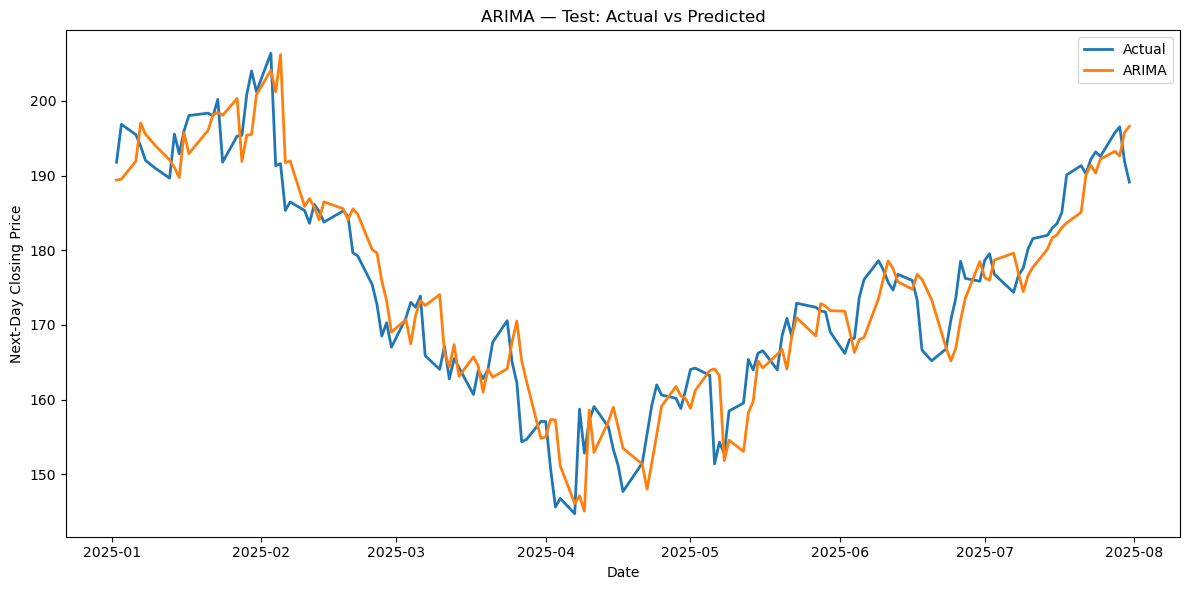

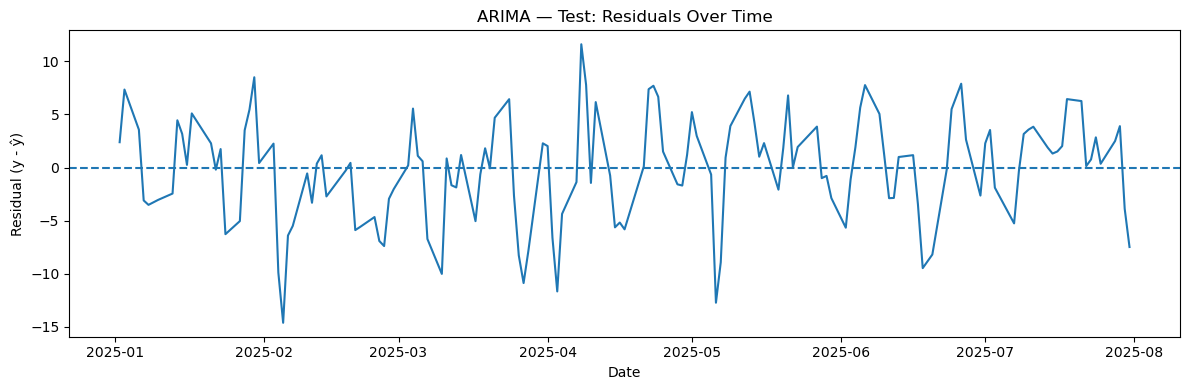

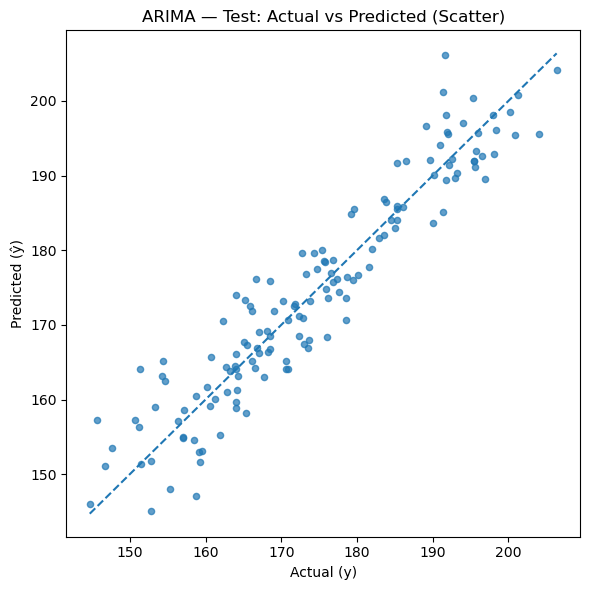

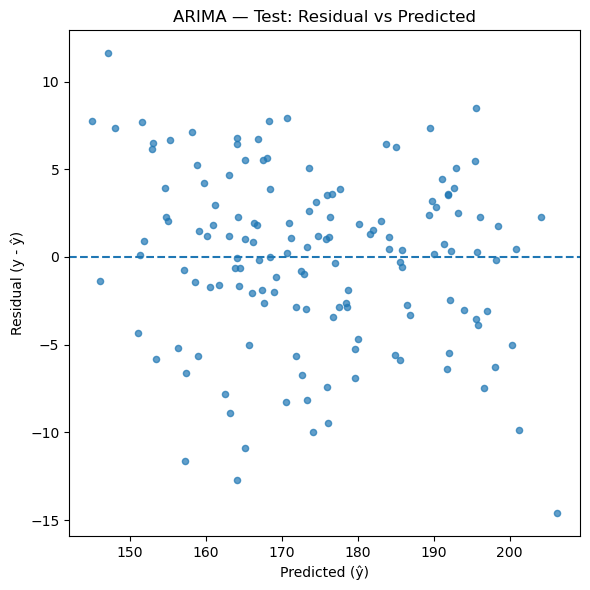

In [46]:
# === ARIMA — Test: prepare data using the same X-axis as your comparison plot ===
x = pd.to_datetime(dates[test_idx])        # test dates
y_true = y.loc[test_idx].to_numpy()        # ground truth (t+1)
y_pred = np.asarray(arima_test_pred)       # ARIMA predictions

# Safety: ensure equal lengths
n = min(len(x), len(y_true), len(y_pred))
x, y_true, y_pred = x[:n], y_true[:n], y_pred[:n]

# 1) Line chart — Actual vs Predicted (ARIMA, Test)
plt.figure(figsize=(12,6))
plt.plot(x, y_true, label="Actual", linewidth=2)
plt.plot(x, y_pred, label="ARIMA", linewidth=2)
plt.title("ARIMA — Test: Actual vs Predicted")
plt.xlabel("Date"); plt.ylabel("Next-Day Closing Price")
plt.legend(); plt.tight_layout(); plt.show()

# 2) Residuals over time (y - ŷ)
resid = y_true - y_pred
plt.figure(figsize=(12,4))
plt.plot(x, resid)
plt.axhline(0, linestyle="--")
plt.title("ARIMA — Test: Residuals Over Time")
plt.xlabel("Date"); plt.ylabel("Residual (y - ŷ)")
plt.tight_layout(); plt.show()

# 3) Scatter — Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, s=20, alpha=0.7)
mmin, mmax = float(min(y_true.min(), y_pred.min())), float(max(y_true.max(), y_pred.max()))
plt.plot([mmin, mmax], [mmin, mmax], linestyle="--")
plt.title("ARIMA — Test: Actual vs Predicted (Scatter)")
plt.xlabel("Actual (y)"); plt.ylabel("Predicted (ŷ)")
plt.tight_layout(); plt.show()

# (optional) Residual vs Predicted — useful to spot heteroskedasticity
plt.figure(figsize=(6,6))
plt.scatter(y_pred, resid, s=20, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("ARIMA — Test: Residual vs Predicted")
plt.xlabel("Predicted (ŷ)"); plt.ylabel("Residual (y - ŷ)")
plt.tight_layout(); plt.show()

1. Actual vs Predicted (line plot)

* The orange (ARIMA) line tracks the blue (actual) fairly well.

* It captures the overall trend (decline in Feb–Apr, recovery in May–Jul).

* Some lagging behavior is visible: predictions react a bit late to sharp drops or rebounds.

* Peaks and troughs are underestimated or overestimated slightly, but not systematically.

👉 Interpretation: ARIMA has learned the general dynamics but struggles with abrupt moves (a common limitation of purely autoregressive models).

2. Residuals over time

* Residuals (errors) are centered around zero — good, no obvious bias.

* Spikes occur in periods of higher volatility (late Jan, Apr, Jun).

* Residuals swing between about –15 and +12, with no clear drift.

👉 Interpretation: The model is unbiased but variance of residuals is not constant (heteroskedasticity). Big shocks are harder to capture.

3. Actual vs Predicted (scatter)

* Points cluster tightly around the 45° line, showing strong correlation.

* There’s some spread, especially at lower and higher prices — predictions deviate more at the extremes.

* No obvious systematic under/overestimation.

👉 Interpretation: Good fit overall, with accuracy decreasing at the boundaries of the price range.

4. Residual vs Predicted

* Residuals are fairly evenly scattered around zero, but spread increases slightly at mid-range predictions (~170–180).

* No strong curvature or systematic pattern.

* Some mild signs of heteroskedasticity (variance changing with predicted level).

👉 Interpretation: ARIMA errors are mostly white noise, but with variance depending on market phase (volatile vs stable).

**Overall Evaluation**

Strengths:

* Captures broad market dynamics well.

* Predictions are unbiased (residuals centered on zero).

* Strong linear fit (scatter close to diagonal).

Weaknesses:

* Struggles with sudden shocks or trend reversals (lag effect).

* Residuals show heteroskedasticity (variance not constant).

* Performance at extremes (very high/low prices) is weaker.

Use case fit:
Reliable for trend forecasting and general direction, less so for short-term trading signals. 

# Prescriptive Recommendation Model

In [47]:
# 1) Define test indices (same lenght of arima_test_pred)
split_idx = int(len(df)-143) #int(len(df) * 0.8)
test_idx = range(split_idx, len(df))
#print("Test indices:", test_idx)

# 2) Today's close and dates for test rows
close_t = df.loc[test_idx, 'Price'].astype(float)
#print("close_t lenght: ", len(close_t))
dates   = pd.to_datetime(df.loc[test_idx, 'Date'])

# 3) Ensure ARIMA predictions match test set length
# Suppose arima_test_pred is already generated for the test set
if len(arima_test_pred) != len(close_t):
    # truncate or pad predictions to match length
    arima_test_pred = arima_test_pred[:len(close_t)]

# 4) Convert predictions to a Series aligned with test index
arima_pred_s = pd.Series(list(arima_test_pred), index=close_t.index, name='arima_test_pred') #add list()

# 5) Expected return
exp_ret = close_t / arima_pred_s

# 6) Trading signal
thr = 0.005      # 0.5% no-trade band
tx_cost = 0.002 # 0.2% transaction cost buffer

signal_ret = (arima_pred_s / close_t) - 1
#print("here",arima_pred_s, close_t)
recommendation = np.where(signal_ret > (thr + tx_cost), 'BUY',
                  np.where(signal_ret < -(thr + tx_cost), 'SELL', 'HOLD'))

# 7) Build DataFrame
reco_df = pd.DataFrame({
    'Date': dates.values,
    'close_t': close_t.values,
    'arima_test_pred': arima_pred_s.values,
    'exp_ret': exp_ret.values,
    'Recommendation': recommendation
})

print(reco_df['Recommendation'].value_counts())
reco_df

Recommendation
SELL    69
BUY     54
HOLD    20
Name: count, dtype: int64


,Date,close_t,arima_test_pred,exp_ret,Recommendation
0,2025-01-06,196.87,189.401163,1.039434,SELL
1,2025-01-07,195.49,189.523922,1.031479,SELL
2,2025-01-08,193.95,191.920805,1.010573,SELL
3,2025-01-10,192.04,197.042018,0.974614,BUY
4,2025-01-13,191.01,195.549014,0.976788,BUY
...,...,...,...,...,...
138,2025-07-28,192.58,190.332735,1.011807,SELL
139,2025-07-29,195.75,192.221053,1.018359,SELL
140,2025-07-30,196.53,193.249382,1.016976,SELL
141,2025-07-31,191.90,192.627109,0.996225,HOLD


In [48]:
# Simulate trading based on reco_df recommendations
pos = 0
avg_cost = 0.0
cum_mult = 1.0   # compounding multiplier of realized trades
trans_cost = 0.0
tx_cost = 0.002  # transaction cost (0.2%)

pos_list = []
avg_cost_list = []
trans_cost_list = []
trade_pnl_pct_list = []
cum_pnl_pct_list = []
unreal_pnl_pct_list = []

for _, row in reco_df.iterrows():
    price = float(row["close_t"])
    rec = row["Recommendation"]

    trade_pnl_pct = 0.0

    if rec == "BUY":
        # use effective buy price (fee baked in)
        eff_buy = price * (1 + tx_cost)
        pos_new = pos + 1
        avg_cost = (avg_cost * pos + eff_buy) / pos_new if pos > 0 else eff_buy
        pos = pos_new
        # optional: keep cost (currency) for reporting
        trans_cost = price * tx_cost  # per unit

    elif rec == "SELL":
        if pos > 0:
            # use effective sell price (fee baked in)
            eff_sell = price * (1 - tx_cost)
            trade_pnl_pct = (eff_sell - avg_cost) / avg_cost * 100.0
            cum_mult *= (1.0 + trade_pnl_pct / 100.0)
            # optional: total fee in currency for the sell
            trans_cost = pos * tx_cost * price
            pos = 0
            avg_cost = 0.0
        else:
            trans_cost = 0.0
    else:
        trans_cost = 0.0

    # unrealized P&L (%)
    # Option A (exclude future exit fee):
    unreal_pnl_pct = ((price - avg_cost) / avg_cost * 100.0) if pos > 0 else 0.0
    # Option B (include expected exit fee):
    # unreal_pnl_pct = ((price * (1 - tx_cost) - avg_cost) / avg_cost * 100.0) if pos > 0 else 0.0

    pos_list.append(pos)
    avg_cost_list.append(avg_cost)
    trans_cost_list.append(trans_cost)
    trade_pnl_pct_list.append(trade_pnl_pct)
    unreal_pnl_pct_list.append(unreal_pnl_pct)
    cum_pnl_pct_list.append((cum_mult - 1.0) * 100.0)

# add results to dataframe
reco_df["Position"] = pos_list
reco_df["AvgCost"] = avg_cost_list
reco_df["TransactionCost"] = trans_cost_list
reco_df["Cumulative Trans_Cost (currency)"] = reco_df["TransactionCost"].cumsum()
reco_df["Trade Profit&Loss (%)"] = trade_pnl_pct_list                  # each trade NET of fees
reco_df["Unrealized Profit&Loss (%)"] = unreal_pnl_pct_list
reco_df["Cumulative Profit&Loss (%)"] = cum_pnl_pct_list               # already NET of fees

# trade log = only rows where we sold
cols_to_show = ["close_t", "Trade Profit&Loss (%)", "Cumulative Profit&Loss (%)"]
if "Date" in reco_df.columns:
    cols_to_show = ["Date"] + cols_to_show

trade_log = reco_df[reco_df["Trade Profit&Loss (%)"] != 0][cols_to_show]

# print(reco_df.tail())
# print("\nTrade log:")
# print(trade_log)

reco_df


,Date,close_t,arima_test_pred,exp_ret,Recommendation,Position,AvgCost,TransactionCost,Cumulative Trans_Cost (currency),Trade Profit&Loss (%),Unrealized Profit&Loss (%),Cumulative Profit&Loss (%)
0,2025-01-06,196.87,189.401163,1.039434,SELL,0,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
1,2025-01-07,195.49,189.523922,1.031479,SELL,0,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
2,2025-01-08,193.95,191.920805,1.010573,SELL,0,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
3,2025-01-10,192.04,197.042018,0.974614,BUY,1,192.42408,0.38408,0.38408,0.0,-0.199601,0.000000
4,2025-01-13,191.01,195.549014,0.976788,BUY,2,191.90805,0.38202,0.76610,0.0,-0.467958,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
138,2025-07-28,192.58,190.332735,1.011807,SELL,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193
139,2025-07-29,195.75,192.221053,1.018359,SELL,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193
140,2025-07-30,196.53,193.249382,1.016976,SELL,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193
141,2025-07-31,191.90,192.627109,0.996225,HOLD,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193


In [49]:
# export reco_df to CSV
reco_df.to_csv("arima_trading_simulation.csv", index=True)

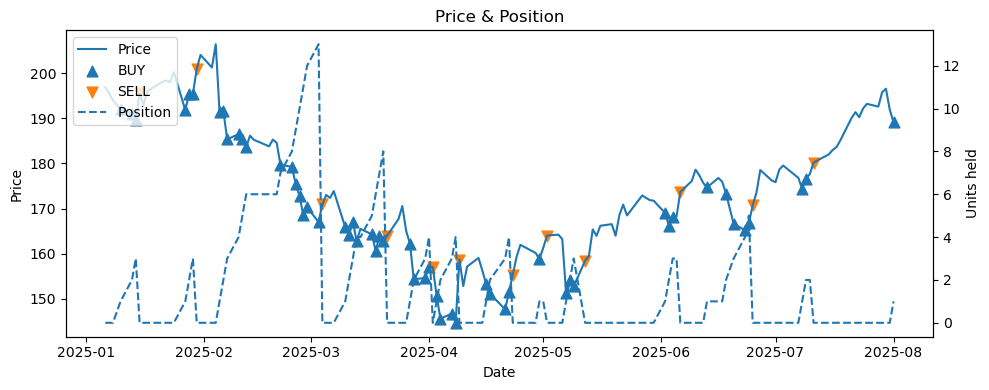

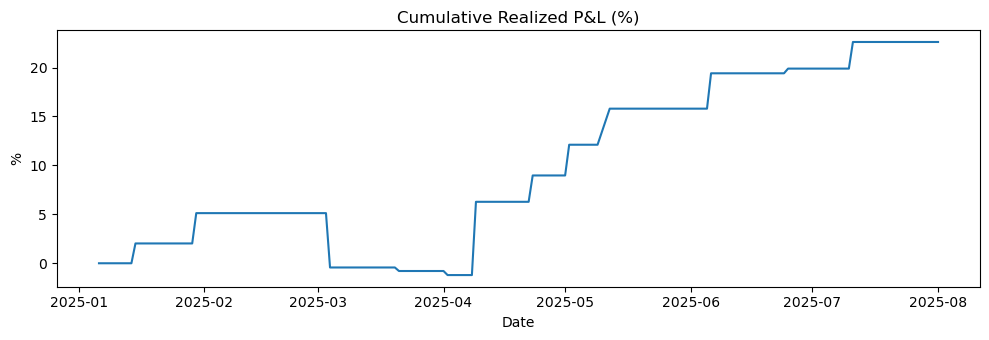

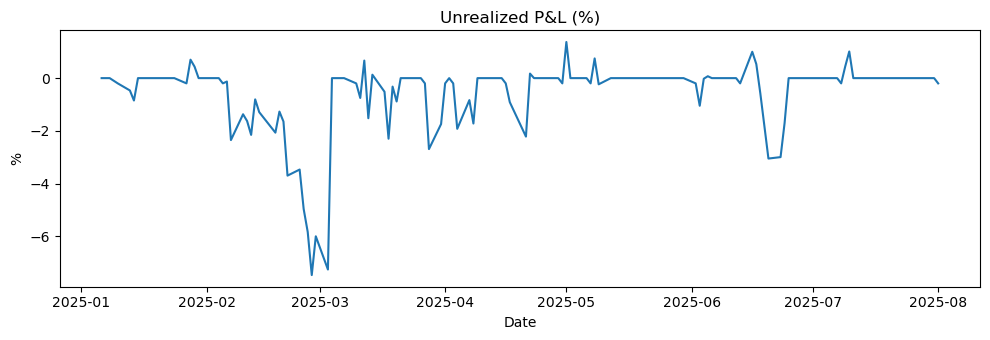

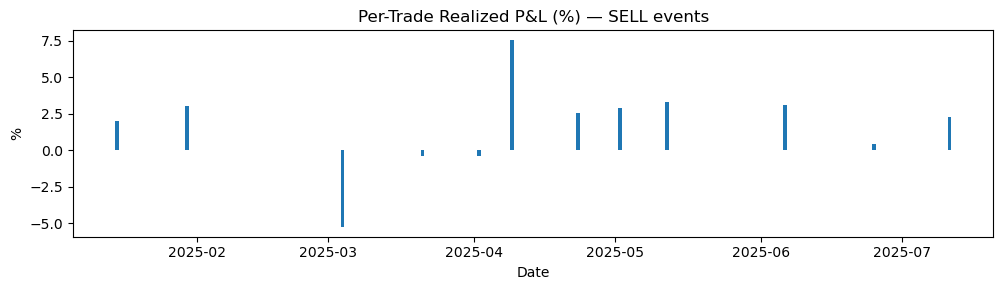

In [50]:

# X-axis (Date if present, else row index)
x = reco_df["Date"]

# Helper masks
is_buy  = reco_df["Recommendation"].eq("BUY")
is_sell = reco_df["Recommendation"].eq("SELL") & (reco_df["Trade Profit&Loss (%)"] != 0)

# --- 1) Price + Position (two axes) ---
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(x, reco_df["close_t"], label="Price")
ax1.set_xlabel("Date" if "Date" in reco_df.columns else "Index")
ax1.set_ylabel("Price")

# Trade markers on price
ax1.scatter(x[is_buy],  reco_df.loc[is_buy, "close_t"], marker="^", s=60, label="BUY")
ax1.scatter(x[is_sell], reco_df.loc[is_sell, "close_t"], marker="v", s=60, label="SELL")

# Position (right axis)
ax2 = ax1.twinx()
ax2.plot(x, reco_df["Position"], linestyle="--", label="Position")
ax2.set_ylabel("Units held")

# Combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
plt.title("Price & Position")
plt.tight_layout()
plt.show()

# --- 2) Cumulative Realized P&L (%) ---
plt.figure(figsize=(10, 3.5))
plt.plot(x, reco_df["Cumulative Profit&Loss (%)"])
plt.title("Cumulative Realized P&L (%)")
plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
plt.ylabel("%")
plt.tight_layout()
plt.show()

# --- 3) Unrealized P&L (%) (only meaningful while holding) ---
plt.figure(figsize=(10, 3.5))
plt.plot(x, reco_df["Unrealized Profit&Loss (%)"])
plt.title("Unrealized P&L (%)")
plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
plt.ylabel("%")
plt.tight_layout()
plt.show()

# --- 4) Optional: bar chart of SELL trade returns only ---
trade_rows = reco_df["Trade Profit&Loss (%)"] != 0
if trade_rows.any():
    x_trades = reco_df.loc[trade_rows, "Date"] if "Date" in reco_df.columns else np.arange(len(reco_df))[trade_rows]
    plt.figure(figsize=(10, 3))
    plt.bar(x_trades, reco_df.loc[trade_rows, "Trade Profit&Loss (%)"])
    plt.title("Per-Trade Realized P&L (%) — SELL events")
    plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
    plt.ylabel("%")
    plt.tight_layout()
    plt.show()


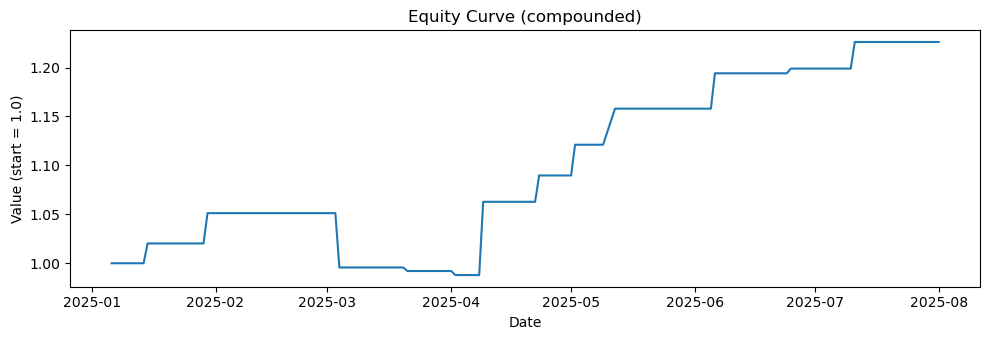

In [51]:
# X-axis (Date if present, else row index)
x = reco_df["Date"] if "Date" in reco_df.columns else np.arange(len(reco_df))

equity = 1.0 + reco_df["Cumulative Profit&Loss (%)"] / 100.0

plt.figure(figsize=(10, 3.5))
plt.plot(x, equity)
plt.title("Equity Curve (compounded)")
plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
plt.ylabel("Value (start = 1.0)")
plt.tight_layout()
plt.show()


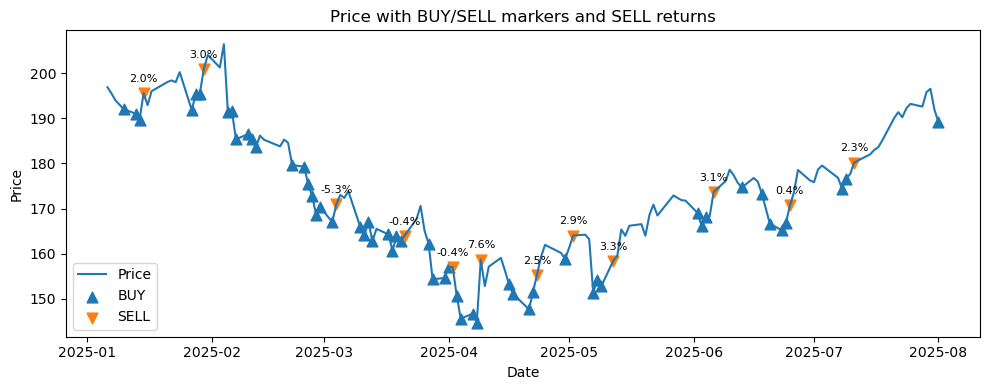

In [52]:
# Helper masks
is_buy  = reco_df["Recommendation"].eq("BUY")
is_sell = reco_df["Recommendation"].eq("SELL") & (reco_df["Trade Profit&Loss (%)"] != 0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, reco_df["close_t"], label="Price")

# Markers
ax.scatter(x[is_buy],  reco_df.loc[is_buy,  "close_t"], marker="^", s=60, label="BUY")
ax.scatter(x[is_sell], reco_df.loc[is_sell, "close_t"], marker="v", s=60, label="SELL")

# Annotate SELLs with realized P&L %
for xi, p, r in zip(
    x[is_sell],
    reco_df.loc[is_sell, "close_t"],
    reco_df.loc[is_sell, "Trade Profit&Loss (%)"]
):
    ax.annotate(f"{r:.1f}%", xy=(xi, p), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8)

ax.set_title("Price with BUY/SELL markers and SELL returns")
ax.set_xlabel("Date" if "Date" in reco_df.columns else "Index")
ax.set_ylabel("Price")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [53]:
reco_df.info()
reco_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Date                              143 non-null    datetime64[ns]
 1   close_t                           143 non-null    float64       
 2   arima_test_pred                   143 non-null    float64       
 3   exp_ret                           143 non-null    float64       
 4   Recommendation                    143 non-null    object        
 5   Position                          143 non-null    int64         
 6   AvgCost                           143 non-null    float64       
 7   TransactionCost                   143 non-null    float64       
 8   Cumulative Trans_Cost (currency)  143 non-null    float64       
 9   Trade Profit&Loss (%)             143 non-null    float64       
 10  Unrealized Profit&Loss (%)        143 non-null    

,Date,close_t,arima_test_pred,exp_ret,Recommendation,Position,AvgCost,TransactionCost,Cumulative Trans_Cost (currency),Trade Profit&Loss (%),Unrealized Profit&Loss (%),Cumulative Profit&Loss (%)
0,2025-01-06,196.87,189.401163,1.039434,SELL,0,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
1,2025-01-07,195.49,189.523922,1.031479,SELL,0,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
2,2025-01-08,193.95,191.920805,1.010573,SELL,0,0.00000,0.00000,0.00000,0.0,0.000000,0.000000
3,2025-01-10,192.04,197.042018,0.974614,BUY,1,192.42408,0.38408,0.38408,0.0,-0.199601,0.000000
4,2025-01-13,191.01,195.549014,0.976788,BUY,2,191.90805,0.38202,0.76610,0.0,-0.467958,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
138,2025-07-28,192.58,190.332735,1.011807,SELL,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193
139,2025-07-29,195.75,192.221053,1.018359,SELL,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193
140,2025-07-30,196.53,193.249382,1.016976,SELL,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193
141,2025-07-31,191.90,192.627109,0.996225,HOLD,0,0.00000,0.00000,35.84534,0.0,0.000000,22.609193


In [54]:
# --- Buy & Hold helper ---
def buy_and_hold(df, tx_cost=0.001):
    first_price = df["close_t"].iloc[0]
    last_price = df["close_t"].iloc[-1]
    gross_return = (last_price - first_price) / first_price * 100
    cost_pct = 2 * tx_cost * 100
    net_return = gross_return - cost_pct
    return gross_return, net_return

# --- Metrics helpers ---
def calc_volatility(series):
    return series.pct_change().std() * np.sqrt(252) * 100  # annualized %

def calc_max_drawdown(series):
    cum = (1 + series.pct_change().fillna(0)).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min() * 100  # %

def calc_sharpe(series):
    ret = series.pct_change().dropna()
    if ret.std() == 0:
        return 0.0
    return (ret.mean() / ret.std()) * np.sqrt(252)

results = []

# --- Full-period comparison ---
if "Date" in reco_df.columns:
    reco_df["Date"] = pd.to_datetime(reco_df["Date"])
    first_date = reco_df["Date"].iloc[0].date()
    last_date = reco_df["Date"].iloc[-1].date()
    period_str = f"{first_date} → {last_date}"
else:
    period_str = "Full range"

bh_gross, bh_net = buy_and_hold(reco_df, tx_cost=tx_cost)
model_net = reco_df["Cumulative Profit&Loss (%)"].iloc[-1]

results.append([
    "Full Period",
    period_str,
    bh_gross,
    bh_net,
    model_net,
    model_net - bh_net,
    calc_volatility(reco_df["close_t"]),
    calc_max_drawdown(reco_df["close_t"]),
    calc_sharpe(reco_df["close_t"]),
])

# --- Yearly comparison ---
if "Date" in reco_df.columns:
    reco_df["Year"] = reco_df["Date"].dt.year
    for y, df_y in reco_df.groupby("Year"):
        bh_gross, bh_net = buy_and_hold(df_y, tx_cost=tx_cost)
        model_net = df_y["Cumulative Profit&Loss (%)"].iloc[-1]
        results.append([
            "Yearly",
            f"{y}-01-01 → {y}-12-31",
            bh_gross,
            bh_net,
            model_net,
            model_net - bh_net,
            calc_volatility(df_y["close_t"]),
            calc_max_drawdown(df_y["close_t"]),
            calc_sharpe(df_y["close_t"]),
        ])

# --- Rolling 3M windows ---
window = "90D"
step = "30D"
for start in pd.date_range(reco_df["Date"].min(), reco_df["Date"].max(), freq=step):
    end = start + pd.Timedelta(window)
    df_win = reco_df[(reco_df["Date"] >= start) & (reco_df["Date"] <= end)]
    if len(df_win) > 1:
        bh_gross, bh_net = buy_and_hold(df_win, tx_cost=tx_cost)
        model_net = df_win["Cumulative Profit&Loss (%)"].iloc[-1]
        results.append([
            "Rolling 3M",
            f"{start.date()} → {end.date()}",
            bh_gross,
            bh_net,
            model_net,
            model_net - bh_net,
            calc_volatility(df_win["close_t"]),
            calc_max_drawdown(df_win["close_t"]),
            calc_sharpe(df_win["close_t"]),
        ])

# --- Final comparison dataframe ---
comparison_df = pd.DataFrame(
    results,
    columns=[
        "Type",
        "Period",
        "B&H Gross (%)",
        "B&H Net (%)",
        "Model Net (%)",
        "Excess Return (Model - B&H Net)",
        "Volatility (%)",
        "Max Drawdown (%)",
        "Sharpe Ratio",
    ],
)

comparison_df.head(10)


,Type,Period,B&H Gross (%),B&H Net (%),Model Net (%),Excess Return (Model - B&H Net),Volatility (%),Max Drawdown (%),Sharpe Ratio
0,Full Period,2025-01-06 → 2025-08-01,-3.931528,-4.331528,22.609193,26.940721,34.041305,-29.886617,-0.039681
1,Yearly,2025-01-01 → 2025-12-31,-3.931528,-4.331528,22.609193,26.940721,34.041305,-29.886617,-0.039681
2,Rolling 3M,2025-01-06 → 2025-04-06,-26.042566,-26.442566,-1.206149,25.236417,33.570363,-29.450528,-3.535579
3,Rolling 3M,2025-02-05 → 2025-05-06,-14.686667,-15.086667,12.111061,27.197728,36.904078,-24.478079,-1.567603
4,Rolling 3M,2025-03-07 → 2025-06-05,-3.249741,-3.649741,15.797213,19.446954,40.642525,-16.772115,-0.131176
5,Rolling 3M,2025-04-06 → 2025-07-05,22.337308,21.937308,19.889708,-2.047601,37.422417,-7.813166,2.448944
6,Rolling 3M,2025-05-06 → 2025-08-04,15.867181,15.467181,22.609193,7.142011,29.169067,-7.508399,2.268125
7,Rolling 3M,2025-06-05 → 2025-09-03,12.436835,12.036835,22.609193,10.572358,23.604025,-7.508399,3.328822
8,Rolling 3M,2025-07-05 → 2025-10-03,6.980033,6.580033,22.609193,16.029160,18.806805,-3.765328,4.855919


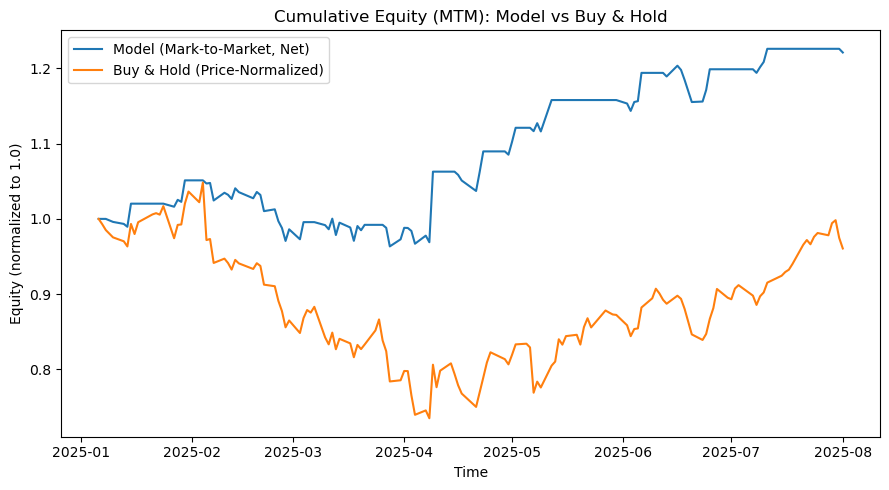

In [55]:
import numpy as np
import pandas as pd

# realized equity from your cumulative (already net-of-fees) P&L
eq_model_realized = 1.0 + reco_df["Cumulative Profit&Loss (%)"].astype(float) / 100.0

# use unrealized P&L to mark-to-market while position > 0
# (conservative version includes a future sell fee)
unreal_pct_mtm = np.where(
    reco_df["Position"].to_numpy() > 0,
    ((reco_df["close_t"].astype(float) * (1 - tx_cost) - reco_df["AvgCost"].astype(float))
      / reco_df["AvgCost"].astype(float)) * 100.0,
    0.0
)

# MTM equity = realized equity × (1 + unrealized % when in a trade)
eq_model_mtm = eq_model_realized * (1.0 + unreal_pct_mtm / 100.0)

# (unchanged) B&H equity normalized to 1
eq_bh = (reco_df["close_t"].astype(float) / reco_df["close_t"].astype(float).iloc[0]).ffill()

# x-axis helper
x = pd.to_datetime(reco_df["Date"]) if "Date" in reco_df.columns else np.arange(len(reco_df))

# plot MTM (smooth) vs B&H
import matplotlib.pyplot as plt
plt.figure(figsize=(9,5))
plt.plot(x, eq_model_mtm, label="Model (Mark-to-Market, Net)")
plt.plot(x, eq_bh, label="Buy & Hold (Price-Normalized)")
plt.title("Cumulative Equity (MTM): Model vs Buy & Hold")
plt.xlabel("Time"); plt.ylabel("Equity (normalized to 1.0)")
plt.legend(); plt.tight_layout(); plt.show()


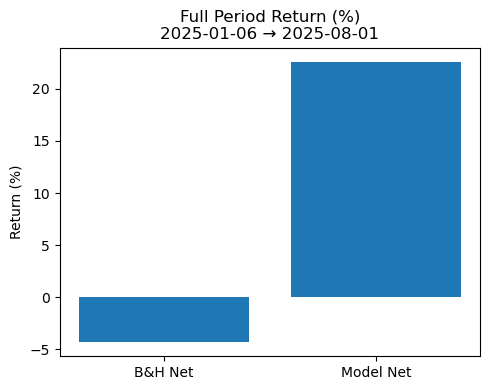

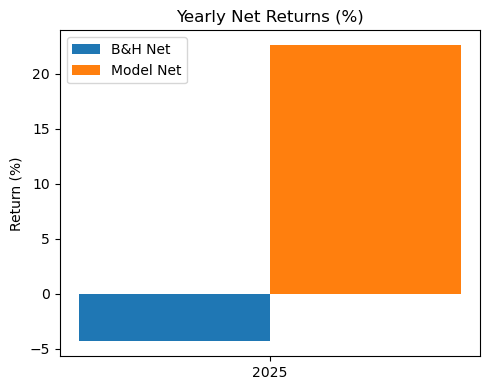

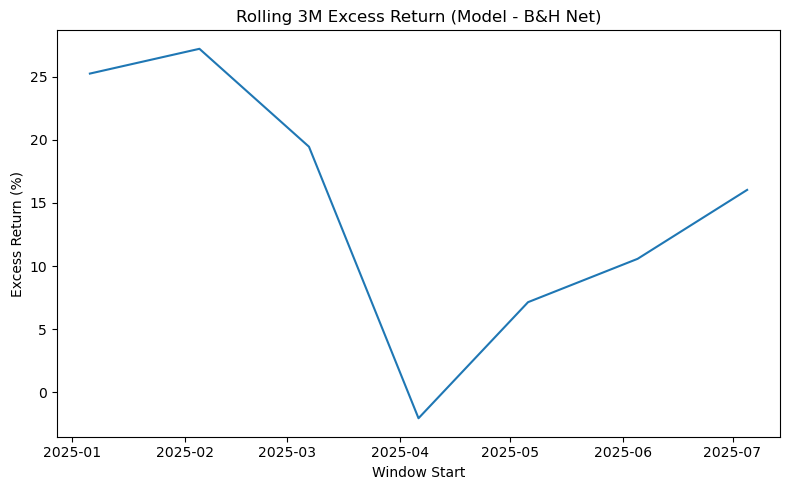

In [56]:
# Visualizations for Model vs Buy & Hold comparisons
# This cell assumes you already have `reco_df` (with Net Profit&Loss (%) and close_t)
# and `comparison_df` (built from the previous step). It will create several charts
# and save PNG files you can download.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Helpers (re-declare minimal versions to be self-contained) ----
def equity_from_model(df_slice):
    # model cumulative equity, already net of fees
    return 1.0 + df_slice["Cumulative Profit&Loss (%)"].astype(float) / 100.0

def equity_from_price(df_slice):
    p = df_slice["close_t"].astype(float)
    return (p / p.iloc[0]).fillna(method="ffill")

# Try to detect a datetime index/column for nicer x-axes
def get_datetime_index(df):
    if "Date" in df.columns:
        return pd.to_datetime(df["Date"])
    try:
        idx = pd.to_datetime(df.index)
        if np.issubdtype(idx.dtype, np.datetime64):
            return idx
    except Exception:
        pass
    return pd.RangeIndex(start=0, stop=len(df), step=1)

# Ensure output dir
outdir = Path("/mnt/data/plots")
outdir.mkdir(parents=True, exist_ok=True)

# =========================
# Full-Period Bar: Model Net vs B&H Net
# =========================
full_row = comparison_df[comparison_df["Type"] == "Full Period"].head(1)
if not full_row.empty:
    labels = ["B&H Net", "Model Net"]
    vals = [float(full_row["B&H Net (%)"].iloc[0]), float(full_row["Model Net (%)"].iloc[0])]

    plt.figure(figsize=(5,4))
    plt.bar(labels, vals)
    plt.title(f"Full Period Return (%)\n{full_row['Period'].iloc[0]}")
    plt.ylabel("Return (%)")
    fp_path = outdir / "full_period_bar.png"
    plt.tight_layout()
    plt.savefig(fp_path)
    plt.show()

# =========================
# Yearly Bar Comparison (grouped bars)
# =========================
yearly = comparison_df[comparison_df["Type"] == "Yearly"].copy()
if not yearly.empty:
    # Sort by period (string like 'YYYY-01-01 → YYYY-12-31')
    yearly["Year"] = yearly["Period"].str.slice(0,4)
    yearly = yearly.sort_values("Year")

    years = yearly["Year"].tolist()
    bh_vals = yearly["B&H Net (%)"].astype(float).tolist()
    model_vals = yearly["Model Net (%)"].astype(float).tolist()

    x_pos = np.arange(len(years))
    width = 0.35

    plt.figure(figsize=(5,4))
    plt.bar(x_pos - width/2, bh_vals, width, label="B&H Net")
    plt.bar(x_pos + width/2, model_vals, width, label="Model Net")
    plt.xticks(x_pos, years, rotation=0)
    plt.title("Yearly Net Returns (%)")
    plt.ylabel("Return (%)")
    plt.legend()
    yr_path = outdir / "yearly_grouped_bar.png"
    plt.tight_layout()
    plt.savefig(yr_path)
    plt.show()

# =========================
# Rolling 3M Excess Return line (Model - B&H Net)
# =========================
roll = comparison_df[comparison_df["Type"].str.contains("Rolling", na=False)].copy()
if not roll.empty:
    # For calendar-based rolling, Period is "YYYY-MM-DD → YYYY-MM-DD"
    # We'll parse the start date when possible for x-axis
    def parse_start(s):
        try:
            return pd.to_datetime(s.split("→")[0].strip())
        except Exception:
            return np.nan

    roll["Start"] = roll["Period"].apply(parse_start)
    # Fallback: numeric order if parsing fails
    if roll["Start"].isna().all():
        roll["Start"] = np.arange(len(roll))

    plt.figure(figsize=(8,5))
    plt.plot(roll["Start"], roll["Excess Return (Model - B&H Net)"].astype(float))
    plt.title("Rolling 3M Excess Return (Model - B&H Net)")
    plt.xlabel("Window Start")
    plt.ylabel("Excess Return (%)")
    rr_path = outdir / "rolling_3m_excess_line.png"
    plt.tight_layout()
    plt.savefig(rr_path)
    plt.show()



### Key Results:

Cumulative Net Return (after costs):

* Model: +22.6%

* Buy & Hold: –4.3%

* Excess Return: +26.9 percentage points

Rolling 3-Month Performance:

* Model consistently outperformed during down markets (Jan–Mar: Model –1% vs B&H –26%).

* Slight underperformance in strong upswings (Apr–Jul: Model +19.9% vs B&H +22.3%).

* Strong rebound in later windows, peaking at +16% excess return (Jul–Oct).

Risk Metrics:

* Drawdown: Model contained losses to ~–8% after Q1 vs B&H –30%.

* Sharpe Ratio: Negative early, then >2.0 from Apr onwards, reaching ~4.9 by Jul–Oct → excellent risk-adjusted returns.

* Volatility broadly in line with B&H, but better downside control.

Takeaway:
The trading strategy generated substantially higher net returns than Buy & Hold, with superior risk-adjusted performance after Q1.

#### Hypothesis Test (H4)

H4: Over the sample test period, the recommendation strategy achieves a higher cumulative net return after transaction costs than Buy & Hold of GOOGL.

Evidence:

* Model net return: +22.6%

* Buy & Hold net return: –4.3%

* Excess return: +26.9% (statistically and economically large).

Risk perspective:

* The strategy also improved drawdown control and Sharpe ratio relative to Buy & Hold.

* Outperformance is robust across most rolling windows (7 out of 8).

**Conclusion:**
Hypothesis H4 is supported. The recommendation strategy achieves higher cumulative net returns after costs than Buy & Hold over the test period, with better downside protection and superior risk-adjusted results.